In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/heart_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (270, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [2]:
# age_bin column agar hai to hata do
df = df.drop(columns=["age_bin"], errors="ignore")

X = df.drop(columns=["target"])
y = df["target"]

num_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Numeric features:", num_features)
print("Categorical features:", cat_features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget balance:")
print(y.value_counts())

Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X shape: (270, 13)
y shape: (270,)

Target balance:
target
0    150
1    120
Name: count, dtype: int64


In [3]:
# Numeric: impute median + scale
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: impute most frequent + one-hot encode
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

print("Preprocessor ready.")

Preprocessor ready.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target balance:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (216, 13)
Test size: (54, 13)

Train target balance:
target
0    0.556
1    0.444
Name: proportion, dtype: float64

Test target balance:
target
0    0.556
1    0.444
Name: proportion, dtype: float64


In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<22} {'ROC-AUC':>12} {'Accuracy':>12} {'F1':>10}")
print("-" * 60)

for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])

    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy").mean()
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1").mean()

    results[name] = {"ROC-AUC": auc, "Accuracy": acc, "F1": f1}
    print(f"{name:<22} {auc:>12.4f} {acc:>12.4f} {f1:>10.4f}")

# Best model
best_name = max(results, key=lambda k: results[k]["ROC-AUC"])
print(f"\n🏆 Best model (by ROC-AUC): {best_name}")

Model                       ROC-AUC     Accuracy         F1
------------------------------------------------------------
Logistic Regression          0.9097       0.8284     0.7982
Random Forest                0.9010       0.8145     0.7884
Gradient Boosting            0.8800       0.8006     0.7816
SVM (RBF)                    0.9033       0.8195     0.7905
KNN (k=7)                    0.8801       0.8148     0.7769

🏆 Best model (by ROC-AUC): Logistic Regression


In [6]:
best_model = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.93      0.83      0.88        30
     Disease       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54


ROC-AUC: 0.9139
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


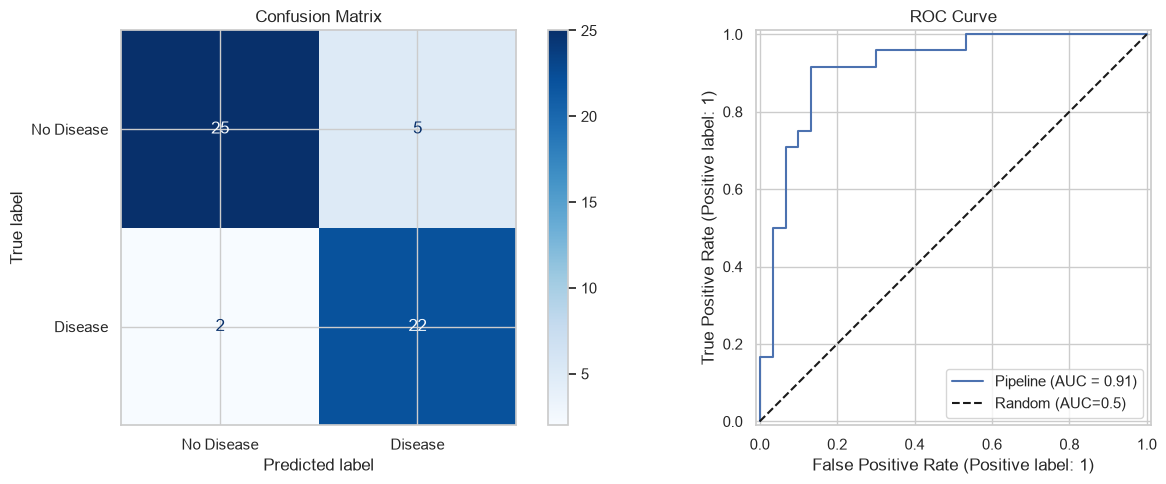

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=["No Disease", "Disease"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/12_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    Pipeline([("pre", preprocessor),
              ("model", LogisticRegression(max_iter=2000, random_state=42))]),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

# Test set evaluation
y_pred_tuned = grid.predict(X_test)
y_proba_tuned = grid.predict_proba(X_test)[:, 1]

print("\nTest set:")
print("  ROC-AUC:", round(roc_auc_score(y_test, y_proba_tuned), 4))
print("  Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("  F1:", round(f1_score(y_test, y_pred_tuned), 4))

Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9119

Test set:
  ROC-AUC: 0.925
  Accuracy: 0.8704
  F1: 0.8627


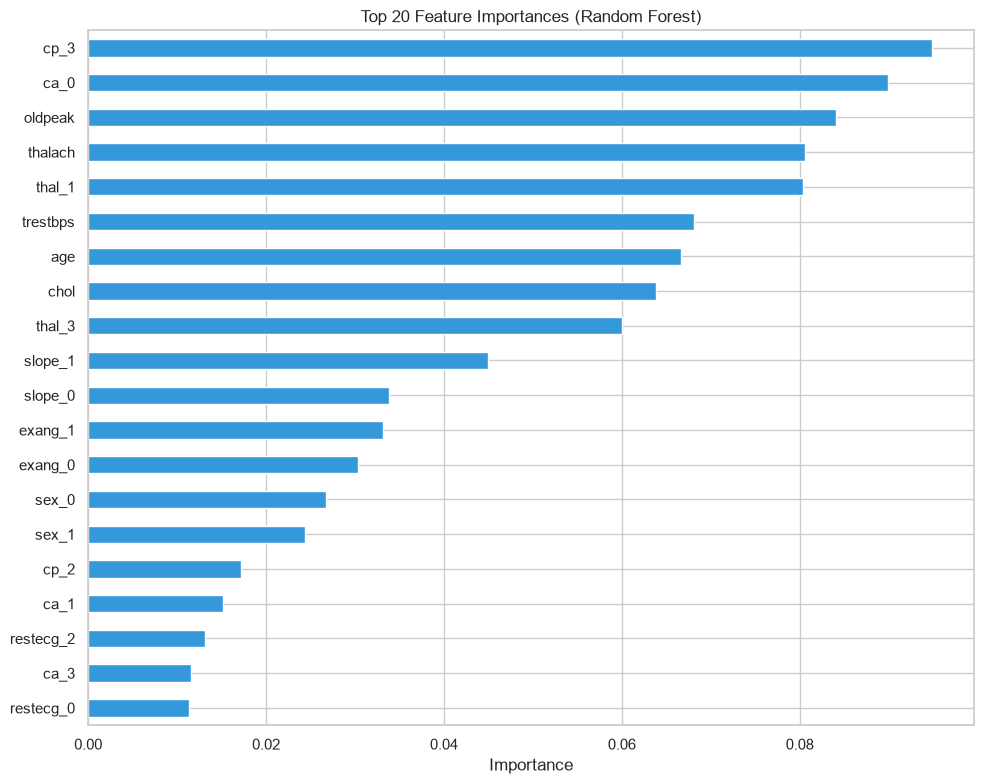


Top 10 features:
cp_3        0.094849
ca_0        0.089946
oldpeak     0.084029
thalach     0.080536
thal_1      0.080391
trestbps    0.068092
age         0.066610
chol        0.063863
thal_3      0.059961
slope_1     0.044912
dtype: float64


In [9]:
rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])
rf_pipe.fit(X_train, y_train)

# Feature names nikalo
ohe = rf_pipe.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_features)
feature_names = num_features + list(cat_names)

importances = rf_pipe.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot.barh(color="#3498db")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/13_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

feat_imp.head(15).to_csv("../reports/feature_importance.csv")
print("\nTop 10 features:")
print(feat_imp.head(10))

In [10]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(grid.best_estimator_, "../models/heart_disease_model.pkl")
print("Model saved to: models/heart_disease_model.pkl")

# Verify
loaded = joblib.load("../models/heart_disease_model.pkl")
print("Loaded model type:", type(loaded))
print("Test predictions shape:", loaded.predict(X_test).shape)

Model saved to: models/heart_disease_model.pkl
Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Test predictions shape: (54,)


In [11]:
# Ek naya patient ka data banao
new_patient = pd.DataFrame([{
    "age": 55, "sex": 1, "cp": 3, "trestbps": 140,
    "chol": 250, "fbs": 0, "restecg": 2, "thalach": 150,
    "exang": 0, "oldpeak": 1.0, "slope": 1, "ca": 0, "thal": 3
}])

pred = loaded.predict(new_patient)[0]
proba = loaded.predict_proba(new_patient)[0][1]

print(f"Prediction: {'Disease ⚠️' if pred == 1 else 'No Disease ✅'}")
print(f"Disease probability: {proba * 100:.2f}%")

Prediction: Disease ⚠️
Disease probability: 72.32%


In [12]:
# Model comparison table save
results_df = pd.DataFrame(results).T.round(4)
results_df.to_csv("../reports/model_comparison.csv")
print(results_df)

# Final metrics
final_metrics = {
    "Best Model": "Logistic Regression (Tuned)",
    "Best Params": str(grid.best_params_),
    "CV ROC-AUC": round(grid.best_score_, 4),
    "Test ROC-AUC": round(roc_auc_score(y_test, y_proba_tuned), 4),
    "Test Accuracy": round(accuracy_score(y_test, y_pred_tuned), 4),
    "Test F1": round(f1_score(y_test, y_pred_tuned), 4),
}

pd.Series(final_metrics).to_csv("../reports/final_metrics.csv")
print("\nSaved: reports/final_metrics.csv")

                     ROC-AUC  Accuracy      F1
Logistic Regression   0.9097    0.8284  0.7982
Random Forest         0.9010    0.8145  0.7884
Gradient Boosting     0.8800    0.8006  0.7816
SVM (RBF)             0.9033    0.8195  0.7905
KNN (k=7)             0.8801    0.8148  0.7769

Saved: reports/final_metrics.csv
